Loading and setting up data


In [1]:
!pip install wordcloud plotly vaderSentiment textblob

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np

In [3]:
import nltk
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [7]:
from google.colab import files
import pandas as pd

uploaded = files.upload()  # choose your CSV
df = pd.read_csv(next(iter(uploaded)))
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Saving iphone17_reddit (2).csv to iphone17_reddit (2).csv
Dataset shape: (2816, 9)
Columns: ['id', 'title', 'author', 'created_utc', 'score', 'upvote_ratio', 'subreddit', 'permalink', 'url']


,id,title,author,created_utc,score,upvote_ratio,subreddit,permalink,url
0,1poc7h4,Unable to scroll through youtube description i...,PinguBoot2000,2025-12-16T20:10:30,2,1.00,youtube,https://www.reddit.com/r/youtube/comments/1poc...,https://www.reddit.com/r/youtube/comments/1poc...
1,1po5wk9,Help pls xoxo,shanerb97,2025-12-16T16:11:17,3,0.81,Smartphones,https://www.reddit.com/r/Smartphones/comments/...,https://www.reddit.com/r/Smartphones/comments/...
2,1pnthar,my discord will not load or send messages even...,SleepyGhostea,2025-12-16T05:01:53,1,1.00,discordapp,https://www.reddit.com/r/discordapp/comments/1...,https://www.reddit.com/r/discordapp/comments/1...
3,1pnpcq8,Great marketing... Make hooman stoopid,SubstantialWar9055,2025-12-16T01:37:55,1,1.00,dbrand,https://www.reddit.com/r/dbrand/comments/1pnpc...,https://www.reddit.com/r/dbrand/comments/1pnpc...
4,1pnow5l,iPhone 17 Pro Max with US Mobile,International-Yak146,2025-12-16T01:16:10,9,0.99,USMobile,https://www.reddit.com/r/USMobile/comments/1pn...,https://www.reddit.com/r/USMobile/comments/1pn...


In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [ ]:
# Initialize resources
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_and_lemmatize(text):
    if not isinstance(text, str):
        return ""

    # 1. Lowercase
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # 3. Remove mentions, hashtags, and other handles (if present)
    text = re.sub(r"[@#]\w+", " ", text)

    # 4. Keep only alphabetic characters and spaces
    text = re.sub(r"[^a-z\s]", " ", text)

    # 5. Collapse multiple spaces
    text = re.sub(r"\s+", " ", text).strip()

    # 6. Tokenize
    tokens = text.split()

    # 7. Remove stopwords
    tokens = [tok for tok in tokens if tok not in stop_words]

    # 8. Lemmatize
    lemmas = [lemmatizer.lemmatize(tok) for tok in tokens]

    # 9. Join back
    return " ".join(lemmas)

# Apply to title column
df["clean_title"] = df["title"].astype(str).apply(clean_and_lemmatize)

df[["title", "clean_title"]].head()

In [10]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_and_lemmatize(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[@#]\w+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = text.split()
    tokens = [tok for tok in tokens if tok not in stop_words]
    lemmas = [lemmatizer.lemmatize(tok) for tok in tokens]
    return " ".join(lemmas)

df["clean_title"] = df["title"].astype(str).apply(clean_and_lemmatize)

In [11]:
print(df.columns.tolist())

['id', 'title', 'author', 'created_utc', 'score', 'upvote_ratio', 'subreddit', 'permalink', 'url', 'clean_title']


Preparing labels and lexicon scores


In [14]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

analyzer = SentimentIntensityAnalyzer()

def get_vader_score(text):
    if not isinstance(text, str) or not text.strip():
        return 0.0
    return analyzer.polarity_scores(text)["compound"]

def get_tb_score(text):
    if not isinstance(text, str) or not text.strip():
        return 0.0
    return TextBlob(text).sentiment.polarity

# Use clean_title here
df["vader_score"] = df["clean_title"].apply(get_vader_score)
df["tb_score"]    = df["clean_title"].apply(get_tb_score)
df["hybrid_score"] = (df["vader_score"] + df["tb_score"]) / 2.0

pos_th = 0.15
neg_th = -0.15

def label_from_hybrid(x):
    if x > pos_th:
        return "positive"
    elif x < neg_th:
        return "negative"
    else:
        return "neutral"

df["sentiment"] = df["hybrid_score"].apply(label_from_hybrid)

In [15]:
df = df.rename(columns={"label": "sentiment"})

In [16]:
# Keep only rows with non‑empty clean_text and valid sentiment label
df = df.dropna(subset=["clean_title", "sentiment"])
df = df[df["clean_title"].str.strip() != ""]

# Standardize text column name to `title` to reuse the old code structure
df["title"] = df["clean_title"].astype(str)

# Ensure sentiment is one of POSITIVE/NEGATIVE/NEUTRAL
df["sentiment"] = df["sentiment"].str.upper().replace({
    "POS": "POSITIVE",
    "NEG": "NEGATIVE"
})
df["sentiment"] = df["sentiment"].where(
    df["sentiment"].isin(["POSITIVE", "NEGATIVE", "NEUTRAL"]),
    "NEUTRAL"
)

df[["title", "sentiment"]].head()

,title,sentiment
0,unable scroll youtube description iphone app,NEGATIVE
1,help pls xoxo,POSITIVE
2,discord load send message even though wifi fine,NEUTRAL
3,great marketing make hooman stoopid,POSITIVE
4,iphone pro max u mobile,NEUTRAL


In [17]:
# Optional: compute lexicon scores for comparison, not for labeling
analyzer = SentimentIntensityAnalyzer()

def get_vader_score(text):
    if not isinstance(text, str) or not text.strip():
        return 0.0
    return analyzer.polarity_scores(text)["compound"]

def get_tb_score(text):
    if not isinstance(text, str) or not text.strip():
        return 0.0
    return TextBlob(text).sentiment.polarity

df_vader_score = df["clean_title"].apply(get_vader_score)
df_tb_score    = df["clean_title"].apply(get_tb_score)
df["hybrid_score"] = df[["vader_score", "tb_score"]].mean(axis=1)

df[["title", "vader_score", "tb_score", "hybrid_score", "sentiment"]].head()

,title,vader_score,tb_score,hybrid_score,sentiment
0,unable scroll youtube description iphone app,0.0000,-0.500000,-0.250000,NEGATIVE
1,help pls xoxo,0.7906,0.000000,0.395300,POSITIVE
2,discord load send message even though wifi fine,-0.2263,0.416667,0.095183,NEUTRAL
3,great marketing make hooman stoopid,0.6249,0.800000,0.712450,POSITIVE
4,iphone pro max u mobile,0.0000,0.000000,0.000000,NEUTRAL


Train/test split and TF‑IDF models

In [18]:
X = df["clean_title"].values
y = df["sentiment"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words="english",
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

In [19]:
# Logistic Regression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_tfidf, y_train)

y_pred_logreg = logreg.predict(X_test_tfidf)
print("Logistic Regression accuracy:", accuracy_score(y_test, y_pred_logreg))
print(classification_report(y_test, y_pred_logreg))

Logistic Regression accuracy: 0.7758007117437722
              precision    recall  f1-score   support

    NEGATIVE       0.89      0.26      0.40        65
     NEUTRAL       0.76      0.98      0.86       384
    POSITIVE       0.88      0.37      0.52       113

    accuracy                           0.78       562
   macro avg       0.84      0.54      0.59       562
weighted avg       0.80      0.78      0.74       562



In [20]:
# Linear SVM
svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)

y_pred_svm = svm.predict(X_test_tfidf)
print("Linear SVM accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Linear SVM accuracy: 0.8523131672597865
              precision    recall  f1-score   support

    NEGATIVE       0.89      0.60      0.72        65
     NEUTRAL       0.85      0.96      0.90       384
    POSITIVE       0.87      0.63      0.73       113

    accuracy                           0.85       562
   macro avg       0.87      0.73      0.78       562
weighted avg       0.85      0.85      0.84       562



LSTM model


In [22]:
# Tokenize text
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(df["title"].values)

X_sequences = tokenizer.texts_to_sequences(df["clean_title"].values)
max_len = 30  # Apple event segments are short; adjust if needed
X_padded = pad_sequences(X_sequences, maxlen=max_len, padding="post", truncating="post")

# Encode labels
label_to_idx = {label: idx for idx, label in enumerate(sorted(df["sentiment"].unique()))}
idx_to_label = {v: k for k, v in label_to_idx.items()}
y_int = df["sentiment"].map(label_to_idx).values
num_classes = len(label_to_idx)
y_cat = to_categorical(y_int, num_classes=num_classes)

X_train_pad, X_test_pad, y_train_cat, y_test_cat, y_train_int, y_test_int = train_test_split(
    X_padded, y_cat, y_int, test_size=0.2, random_state=42, stratify=y_int
)

In [23]:
tokenizer = Tokenizer(num_words=10000, oov_token="OOV")
tokenizer.fit_on_texts(df["clean_title"].values)

In [24]:
vocab_size = min(10000, len(tokenizer.word_index) + 1)
embedding_dim = 64

lstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    LSTM(64, return_sequences=False),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

lstm_model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

history = lstm_model.fit(
    X_train_pad,
    y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 13s 71ms/step - accuracy: 0.6313 - loss: 0.9441 - val_accuracy: 0.7127 - val_loss: 0.7981
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.6761 - loss: 0.8565 - val_accuracy: 0.7127 - val_loss: 0.7807
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6722 - loss: 0.8614 - val_accuracy: 0.7127 - val_loss: 0.7818
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6917 - loss: 0.8268 - val_accuracy: 0.7439 - val_loss: 0.7907
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7846 - loss: 0.5940 - val_accuracy: 0.6815 - val_loss: 0.7805
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8164 - loss: 0.4144 - val_accuracy: 0.7817 - val_loss: 0.6711
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8595 - loss: 0.2893 - val_accuracy: 0.7884 - val_loss: 0.7068
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8575 - loss: 0.2626 - val_accuracy: 0.7996 - 

In [25]:
# Evaluate LSTM
loss, acc = lstm_model.evaluate(X_test_pad, y_test_cat, verbose=0)
print("LSTM test accuracy:", acc)

y_proba_lstm = lstm_model.predict(X_test_pad)
y_pred_lstm_int = np.argmax(y_proba_lstm, axis=1)
y_pred_lstm = [idx_to_label[i] for i in y_pred_lstm_int]

print(classification_report([idx_to_label[i] for i in y_test_int], y_pred_lstm))

LSTM test accuracy: 0.7651245594024658
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
              precision    recall  f1-score   support

    NEGATIVE       0.35      0.45      0.39        65
     NEUTRAL       0.88      0.87      0.87       384
    POSITIVE       0.67      0.60      0.63       113

    accuracy                           0.77       562
   macro avg       0.63      0.64      0.63       562
weighted avg       0.78      0.77      0.77       562



Attach predictions

In [29]:
# Predict for all rows
all_proba = lstm_model.predict(X_padded)
all_pred_int = np.argmax(all_proba, axis=1)
df["lstm_pred"] = [idx_to_label[i] for i in all_pred_int]

if "POSITIVE" in label_to_idx:
    pos_idx = label_to_idx["POSITIVE"]
    df["lstm_pos_prob"] = all_proba[:, pos_idx]
else:
    df["lstm_pos_prob"] = all_proba.max(axis=1)

# Add classical model predictions (on full data)
X_all_tfidf = tfidf.transform(df["title"].values)
df["logreg_pred"] = logreg.predict(X_all_tfidf)
df["svm_pred"] = svm.predict(X_all_tfidf)

df[["clean_title", "sentiment", "logreg_pred", "svm_pred", "lstm_pred", "lstm_pos_prob"]].head()

88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


,clean_title,sentiment,logreg_pred,svm_pred,lstm_pred,lstm_pos_prob
0,unable scroll youtube description iphone app,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,0.333353
1,help pls xoxo,POSITIVE,POSITIVE,POSITIVE,POSITIVE,0.934574
2,discord load send message even though wifi fine,NEUTRAL,NEUTRAL,NEUTRAL,NEUTRAL,0.000553
3,great marketing make hooman stoopid,POSITIVE,POSITIVE,POSITIVE,POSITIVE,0.934741
4,iphone pro max u mobile,NEUTRAL,NEUTRAL,NEUTRAL,NEUTRAL,0.001261


Simple result tables


In [31]:
# Map sentiment to numeric for sorting if needed
sent_to_num = {"NEGATIVE": -1, "NEUTRAL": 0, "POSITIVE": 1}
df["sentiment_num_mapped"] = df["sentiment"].map(sent_to_num)

most_positive = df.sort_values("lstm_pos_prob", ascending=False).head(10)
most_negative = df.sort_values("lstm_pos_prob", ascending=True).head(10)

print("Most positive by LSTM:")
display(most_positive[["clean_title", "sentiment", "lstm_pred", "lstm_pos_prob"]])

print("Most negative by LSTM:")
display(most_negative[[ "clean_title", "sentiment", "lstm_pred", "lstm_pos_prob"]])

Most positive by LSTM:


,clean_title,sentiment,lstm_pred,lstm_pos_prob
553,lemon easy way get instant gift card take min ...,POSITIVE,POSITIVE,0.939473
552,lemon easy way get instant gift card take min ...,POSITIVE,POSITIVE,0.939473
380,hi heard iphone smartphone price going rise ai...,POSITIVE,POSITIVE,0.937624
522,help finding best portable dac,POSITIVE,POSITIVE,0.935246
442,best value tws buat harga k,POSITIVE,POSITIVE,0.935218
441,best value tws harga k,POSITIVE,POSITIVE,0.935169
756,best amazon deal today hand picked,POSITIVE,POSITIVE,0.935113
2534,vicseed magsafe car mount upgraded strongest m...,POSITIVE,POSITIVE,0.935038
2331,good strong clear case base iphone,POSITIVE,POSITIVE,0.935021
986,iphone base best iphone release year almost pe...,POSITIVE,POSITIVE,0.935000


Most negative by LSTM:


,clean_title,sentiment,lstm_pred,lstm_pos_prob
1688,debating returning returning se,NEUTRAL,NEUTRAL,0.000515
1884,sell rep curious buyer,NEUTRAL,NEUTRAL,0.000516
800,cash cc purchasing,NEUTRAL,NEUTRAL,0.000523
2038,selfie log video working iphone pro max,NEUTRAL,NEUTRAL,0.000525
2037,selfie log video working iphone pro max,NEUTRAL,NEUTRAL,0.000525
327,battery drain normal,NEUTRAL,NEUTRAL,0.000526
1692,sim recognize iphone,NEUTRAL,NEUTRAL,0.000526
2700,awe dropping event megathread,NEUTRAL,NEUTRAL,0.000526
864,awe dropping event megathread,NEUTRAL,NEUTRAL,0.000526
1231,sim issue anyone,NEUTRAL,NEUTRAL,0.000527


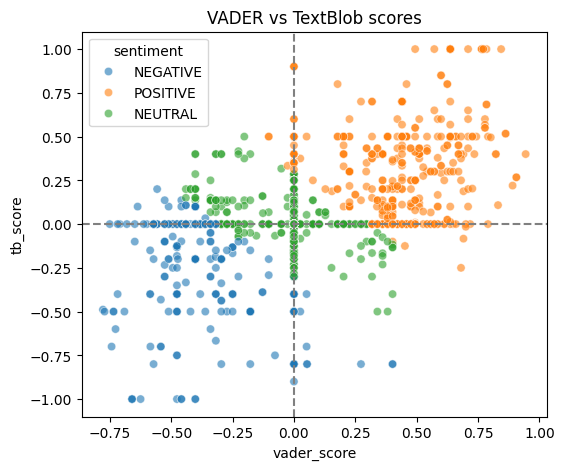

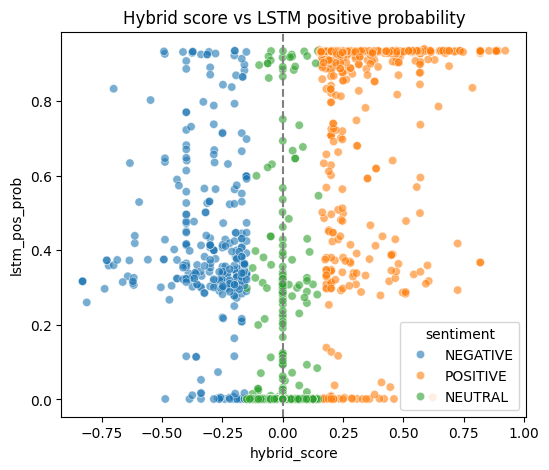

In [32]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    x="vader_score", y="tb_score",
    hue="sentiment", data=df, alpha=0.6
)
plt.axvline(0, color="gray", linestyle="--")
plt.axhline(0, color="gray", linestyle="--")
plt.title("VADER vs TextBlob scores")
plt.show()

plt.figure(figsize=(6,5))
sns.scatterplot(
    x="hybrid_score", y="lstm_pos_prob",
    hue="sentiment", data=df, alpha=0.6
)
plt.axvline(0, color="gray", linestyle="--")
plt.title("Hybrid score vs LSTM positive probability")
plt.show()

In [33]:
# Numeric overview: count, mean, std, min, 25%, 50% (median), 75%, max
df.describe()

,score,upvote_ratio,vader_score,tb_score,hybrid_score,lstm_pos_prob,sentiment_num_mapped
count,2807.000000,2807.000000,2807.000000,2807.000000,2807.000000,2807.000000,2807.000000
mean,97.109369,0.713548,0.042041,0.039817,0.040929,0.220073,0.084432
std,451.975038,0.258443,0.253968,0.243372,0.215390,0.348638,0.557138
min,0.000000,0.080000,-0.778300,-1.000000,-0.829850,0.000515,-1.000000
25%,0.000000,0.500000,0.000000,0.000000,0.000000,0.000618,0.000000
50%,1.000000,0.760000,0.000000,0.000000,0.000000,0.000833,0.000000
75%,9.000000,0.980000,0.000000,0.000000,0.073508,0.347035,0.000000
max,15698.000000,1.000000,0.944200,1.000000,0.922100,0.939473,1.000000


In [34]:
# Sentiment distribution (mode for labels)
df["sentiment"].value_counts(dropna=False)

,count
sentiment,
NEUTRAL,1916
POSITIVE,564
NEGATIVE,327


Sentiment class plots

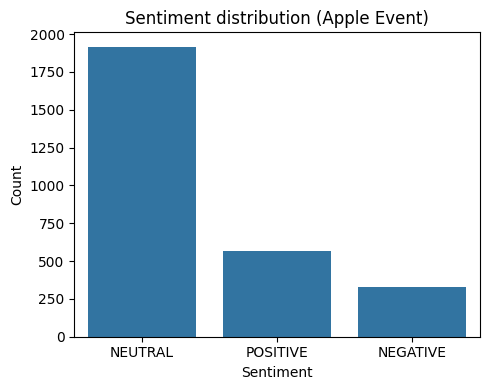

In [36]:
plt.figure(figsize=(5,4))
sns.countplot(x="sentiment", data=df, order=df["sentiment"].value_counts().index)
plt.title("Sentiment distribution (Apple Event)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Score distributions

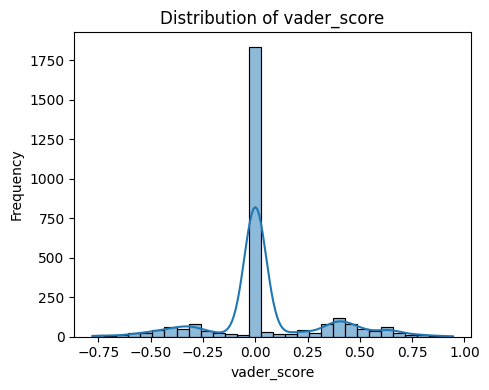

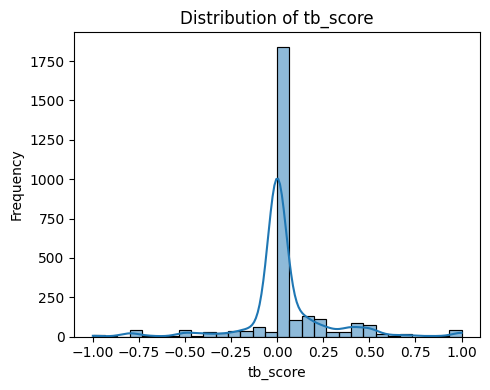

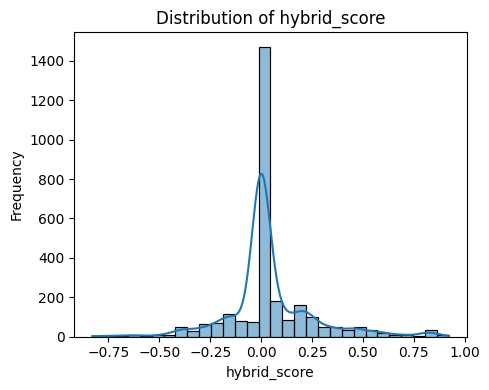

In [37]:
score_cols = ["vader_score", "tb_score", "hybrid_score"]
for col in score_cols:
    if col in df.columns:
        plt.figure(figsize=(5,4))
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()

Classification reports and accuracy

In [38]:
from sklearn.metrics import classification_report, accuracy_score

# Logistic Regression
y_pred_logreg = logreg.predict(X_test_tfidf)
print("Logistic Regression accuracy:", accuracy_score(y_test, y_pred_logreg))
print(classification_report(y_test, y_pred_logreg))

# Linear SVM
y_pred_svm = svm.predict(X_test_tfidf)
print("Linear SVM accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Logistic Regression accuracy: 0.7758007117437722
              precision    recall  f1-score   support

    NEGATIVE       0.89      0.26      0.40        65
     NEUTRAL       0.76      0.98      0.86       384
    POSITIVE       0.88      0.37      0.52       113

    accuracy                           0.78       562
   macro avg       0.84      0.54      0.59       562
weighted avg       0.80      0.78      0.74       562

Linear SVM accuracy: 0.8523131672597865
              precision    recall  f1-score   support

    NEGATIVE       0.89      0.60      0.72        65
     NEUTRAL       0.85      0.96      0.90       384
    POSITIVE       0.87      0.63      0.73       113

    accuracy                           0.85       562
   macro avg       0.87      0.73      0.78       562
weighted avg       0.85      0.85      0.84       562



In [58]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Train NB on the TF-IDF features you already have
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

y_pred_nb = nb.predict(X_test_tfidf)

print("Naive Bayes")
print("Accuracy", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes
Accuracy 0.7259786476868327
              precision    recall  f1-score   support

    NEGATIVE       1.00      0.08      0.14        65
     NEUTRAL       0.72      1.00      0.83       384
    POSITIVE       0.91      0.18      0.30       113

    accuracy                           0.73       562
   macro avg       0.87      0.42      0.42       562
weighted avg       0.79      0.73      0.65       562



In [39]:
# LSTM
loss, acc = lstm_model.evaluate(X_test_pad, y_test_cat, verbose=0)
print("LSTM test accuracy:", acc)

y_proba_lstm = lstm_model.predict(X_test_pad)
y_pred_lstm_int = np.argmax(y_proba_lstm, axis=1)
y_pred_lstm = [idx_to_label[i] for i in y_pred_lstm_int]

print(classification_report([idx_to_label[i] for i in y_test_int], y_pred_lstm))

LSTM test accuracy: 0.7651245594024658
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
              precision    recall  f1-score   support

    NEGATIVE       0.35      0.45      0.39        65
     NEUTRAL       0.88      0.87      0.87       384
    POSITIVE       0.67      0.60      0.63       113

    accuracy                           0.77       562
   macro avg       0.63      0.64      0.63       562
weighted avg       0.78      0.77      0.77       562



Model comparison table

In [40]:
metrics_rows = []

# LogReg
metrics_rows.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_logreg)
})

# SVM
metrics_rows.append({
    "Model": "Linear SVM",
    "Accuracy": accuracy_score(y_test, y_pred_svm)
})

# LSTM
metrics_rows.append({
    "Model": "LSTM",
    "Accuracy": acc
})

model_results = pd.DataFrame(metrics_rows)
model_results

,Model,Accuracy
0,Logistic Regression,0.775801
1,Linear SVM,0.852313
2,LSTM,0.765125


In [41]:
# Attach predictions for all rows
X_all_tfidf = tfidf.transform(df["title"].values)
df["logreg_pred"] = logreg.predict(X_all_tfidf)
df["svm_pred"] = svm.predict(X_all_tfidf)

all_seq = tokenizer.texts_to_sequences(df["title"].values)
all_pad = pad_sequences(all_seq, maxlen=max_len, padding="post", truncating="post")
all_proba = lstm_model.predict(all_pad)
all_pred_int = np.argmax(all_proba, axis=1)
df["lstm_pred"] = [idx_to_label[i] for i in all_pred_int]

if "POSITIVE" in label_to_idx:
    df["lstm_pos_prob"] = all_proba[:, label_to_idx["POSITIVE"]]
else:
    df["lstm_pos_prob"] = all_proba.max(axis=1)

88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [44]:
# Most positive / most negative segments by LSTM probability
most_pos = df.sort_values("lstm_pos_prob", ascending=False).head(10)
most_neg = df.sort_values("lstm_pos_prob", ascending=True).head(10)

print("Most positive segments:")
display(most_pos[[ "clean_title", "sentiment", "logreg_pred", "svm_pred", "lstm_pred", "lstm_pos_prob"]])

print("Most negative segments:")
display(most_neg[[ "clean_title", "sentiment", "logreg_pred", "svm_pred", "lstm_pred", "lstm_pos_prob"]])

Most positive segments:


,clean_title,sentiment,logreg_pred,svm_pred,lstm_pred,lstm_pos_prob
553,lemon easy way get instant gift card take min ...,POSITIVE,POSITIVE,POSITIVE,POSITIVE,0.939473
552,lemon easy way get instant gift card take min ...,POSITIVE,POSITIVE,POSITIVE,POSITIVE,0.939473
380,hi heard iphone smartphone price going rise ai...,POSITIVE,NEUTRAL,POSITIVE,POSITIVE,0.937624
522,help finding best portable dac,POSITIVE,POSITIVE,POSITIVE,POSITIVE,0.935246
442,best value tws buat harga k,POSITIVE,POSITIVE,POSITIVE,POSITIVE,0.935218
441,best value tws harga k,POSITIVE,POSITIVE,POSITIVE,POSITIVE,0.935169
756,best amazon deal today hand picked,POSITIVE,POSITIVE,POSITIVE,POSITIVE,0.935113
2534,vicseed magsafe car mount upgraded strongest m...,POSITIVE,POSITIVE,POSITIVE,POSITIVE,0.935038
2331,good strong clear case base iphone,POSITIVE,POSITIVE,POSITIVE,POSITIVE,0.935021
986,iphone base best iphone release year almost pe...,POSITIVE,POSITIVE,POSITIVE,POSITIVE,0.935000


Most negative segments:


,clean_title,sentiment,logreg_pred,svm_pred,lstm_pred,lstm_pos_prob
1688,debating returning returning se,NEUTRAL,NEUTRAL,NEUTRAL,NEUTRAL,0.000515
1884,sell rep curious buyer,NEUTRAL,NEUTRAL,NEUTRAL,NEUTRAL,0.000516
800,cash cc purchasing,NEUTRAL,NEUTRAL,NEUTRAL,NEUTRAL,0.000523
2038,selfie log video working iphone pro max,NEUTRAL,NEUTRAL,NEUTRAL,NEUTRAL,0.000525
2037,selfie log video working iphone pro max,NEUTRAL,NEUTRAL,NEUTRAL,NEUTRAL,0.000525
327,battery drain normal,NEUTRAL,NEUTRAL,NEUTRAL,NEUTRAL,0.000526
1692,sim recognize iphone,NEUTRAL,NEUTRAL,NEUTRAL,NEUTRAL,0.000526
2700,awe dropping event megathread,NEUTRAL,NEUTRAL,NEUTRAL,NEUTRAL,0.000526
864,awe dropping event megathread,NEUTRAL,NEUTRAL,NEUTRAL,NEUTRAL,0.000526
1231,sim issue anyone,NEUTRAL,NEUTRAL,NEUTRAL,NEUTRAL,0.000527


Score / upvote ratio vs sentiment


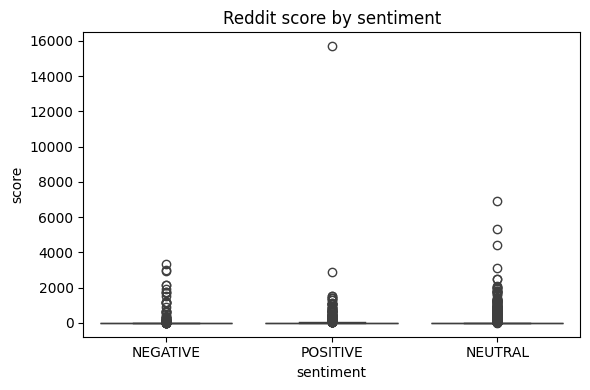

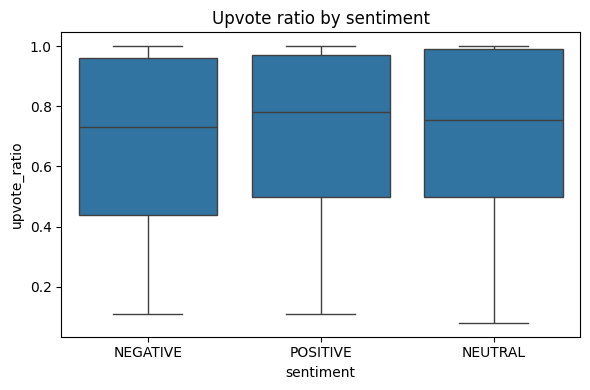

In [49]:
plt.figure(figsize=(6, 4))
sns.boxplot(x="sentiment", y="score", data=df)
plt.title("Reddit score by sentiment")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(x="sentiment", y="upvote_ratio", data=df)
plt.title("Upvote ratio by sentiment")
plt.tight_layout()
plt.show()

Hybrid score plots

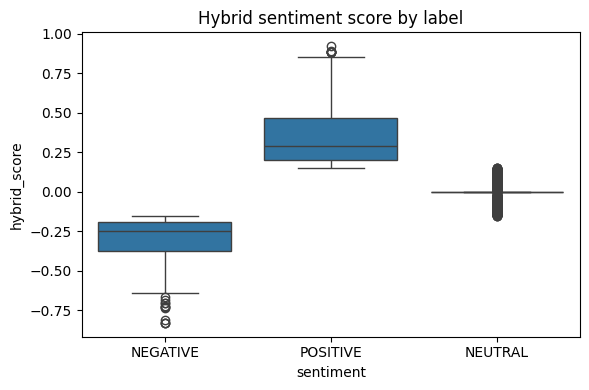

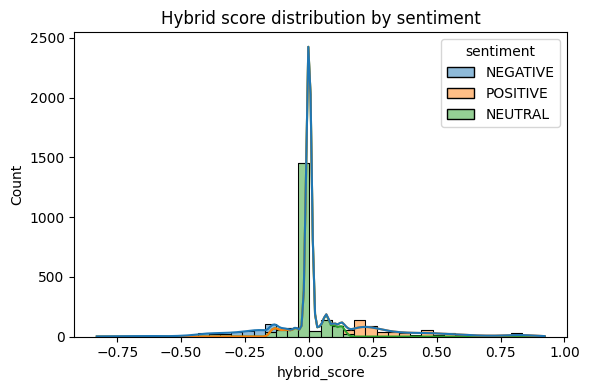

In [50]:
plt.figure(figsize=(6, 4))
sns.boxplot(x="sentiment", y="hybrid_score", data=df)
plt.title("Hybrid sentiment score by label")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.histplot(data=df, x="hybrid_score", hue="sentiment",
             bins=40, kde=True, multiple="stack")
plt.title("Hybrid score distribution by sentiment")
plt.tight_layout()
plt.show()

Top‑N subreddits by sentiment


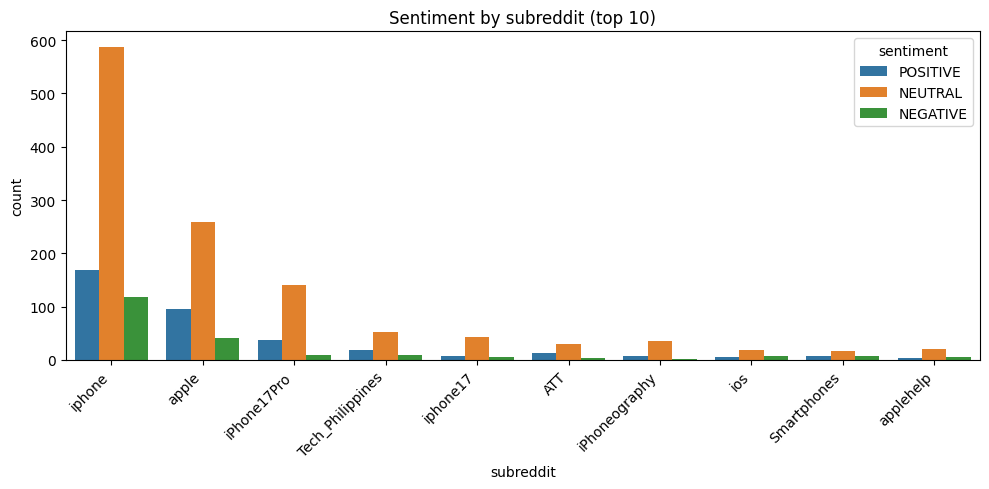

In [51]:
top_n = 10
top_subs = df["subreddit"].value_counts().head(top_n).index
df_top = df[df["subreddit"].isin(top_subs)]

plt.figure(figsize=(10, 5))
sns.countplot(x="subreddit", hue="sentiment", data=df_top,
              order=top_subs)
plt.xticks(rotation=45, ha="right")
plt.title("Sentiment by subreddit (top 10)")
plt.tight_layout()
plt.show()

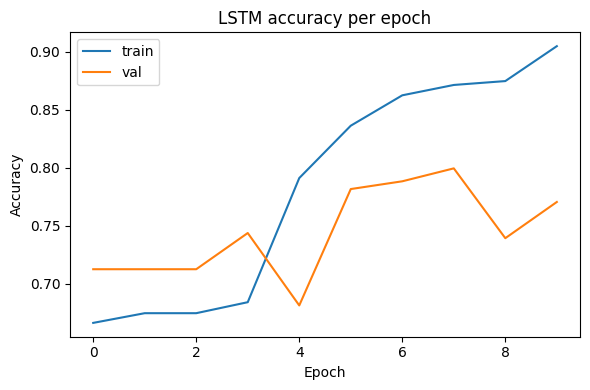

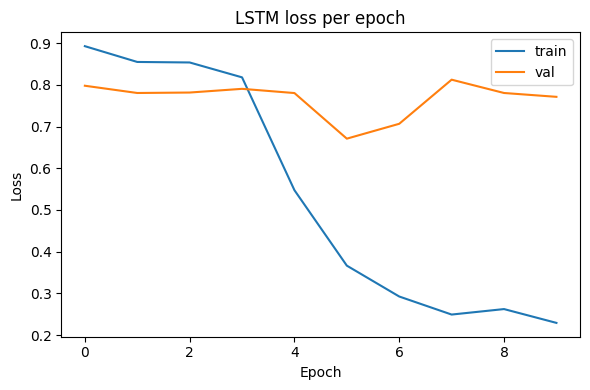

In [53]:
plt.figure(figsize=(6, 4))
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("LSTM accuracy per epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("LSTM loss per epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

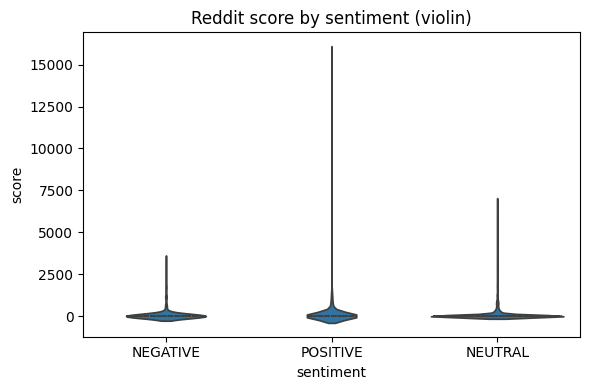

In [63]:
plt.figure(figsize=(6,4))
sns.violinplot(x="sentiment", y="score", data=df, inner="quartile")
plt.title("Reddit score by sentiment (violin)")
plt.tight_layout()
plt.show()

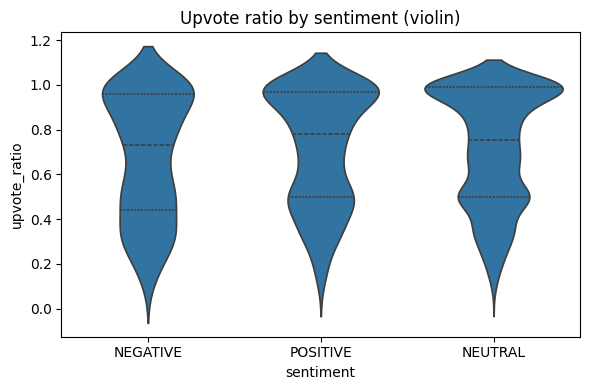

In [64]:
plt.figure(figsize=(6,4))
sns.violinplot(x="sentiment", y="upvote_ratio", data=df, inner="quartile")
plt.title("Upvote ratio by sentiment (violin)")
plt.tight_layout()
plt.show()